# Table of contents

- **Introduction**
- **Objective**
- **Project Overview**
- **K-Means Foundations**
- **Setup Environments**
- **K-Means Initialization Sensitivity**
- **Optimal Number of Clusters**
    * Elbow Method
    * **Alternative Methods**
        * Silhouette Score
        * Calinski-Harabasz Index
        * Davies-Bouldin Index
- **Each Method Result Comparisons**
- **Conclusion**

# Introduction

This tutorial introduces K-Means clustering, an unsupervised learning algorithm, using Python and the scikit-learn library. We will walk through the process of applying K-Means to synthetic and real-world data (image clustering), exploring key concepts, implementing the algorithm, and determining the optimal number of clusters using the elbow method. Each section includes theoretical explanations, step-by-step code, and visualizations to reinforce understanding.

# Objective

**Project Objective**

The primary objective of this project is to master the application and evaluation of the K-Means clustering algorithm using Python's Scikit-learn library. Specifically, the goal is to develop a robust methodology for determining the optimal number of clusters (K) by comparing and contrasting various evaluation techniques.

The specific objectives are to:

- Understand and Implement the core iterative steps of the K-Means algorithm.
- Evaluate and Mitigate the impact of initialization sensitivity through techniques like K-Means++ and multiple runs (n_init).
- Apply and Interpret heuristic and quantitative metrics to determine the optimal K, including the Elbow Method (Inertia), Silhouette Score, Calinski-Harabasz Index, and Davies-Bouldin Index.
- Demonstrate the practical utility of clustering through an application like image quantization (as mentioned in the Introduction).

# Project Overview

This project serves as a hands-on tutorial and comparative analysis framework for K-Means clustering. It systematically guides the user from theoretical understanding to practical, multi-metric cluster validation.

**Phase 1: Foundational Understanding and Setup**

The project begins by establishing the theoretical basis of K-Means, including the concepts of Centroids, Inertia (WCSS), and the Expectation-Maximization (E-M) steps. A synthetic, well-defined dataset is created as a consistent benchmark for all subsequent analysis.

**Phase 2: Addressing Algorithm Sensitivity**

This phase focuses on the critical issue of Initialization Sensitivity. By creating a simple dataset (points on a unit circle) and varying the `random_state` with `n_init=1`, the project visually demonstrates how the choice of starting centroids can lead to different local minima, thus highlighting why modern implementations rely on techniques like K-Means++ and multiple initialization runs (`n_init`).

**Phase 3: Comprehensive Optimal K Determination**

This is the core analytical phase, where four distinct methods are run and compared:

- **Elbow Method (Inertia):** K-Means is run for a range of K values, and the Inertia is plotted to visually identify the "elbow" point of diminishing returns.

- **Quantitative Metric Analysis:** For K≥2, the model is run, and three quantitative scores are calculated:
    - **Silhouette Score:** Optimized for maximum separation and cohesion.
    - **Calinski-Harabasz Index:** Optimized for maximum ratio of between-cluster to within-cluster variance.
    - **Davies-Bouldin Index:** Optimized for minimum cluster overlap/similarity.

**Phase 4: Comparative Result Interpretation**

The final phase compares the recommendations of all four methods. It is demonstrated that metrics focusing heavily on separation (like Silhouette and DBI) may favor highly merged clusters (e.g., K=2), while metrics prioritizing granular structure (like CHI and Elbow) may favor the ground truth (K=4). This comparison is crucial for understanding the subjectivity inherent in cluster validation and informing the final choice of K.

# K-Means Foundations

K-Means is a **centroid-based clustering algorithm** that partitions a dataset into k distinct, non-overlapping subgroups (clusters) by minimizing the **sum of squared distances (often called Inertia or Within-Cluster Sum of Squares (WCSS))** between each data point and the mean of its assigned cluster. It is an **unsupervised learning technique**, working with unlabeled data to discover inherent patterns or groupings.

**Key Concepts and Underlying Principles**

- **Clusters** : Groups of data points that are similar to each other, based on a distance metric (typically Euclidean distance), while being dissimilar to points in other clusters.
- **Centroids** : The mean (center of mass) of all points currently assigned to a cluster, representing the cluster's location in the feature space.
- **Inertia (WCSS)** : The **objective function** K-Means seeks to minimize. It's the sum of squared distances from each point to its assigned centroid. Minimizing inertia produces more compact, denser clusters.
- **Initialization Sensitivity** : K-Means is sensitive to the initial placement of centroids. Poor initialization can lead to converging on a local minimum of the inertia function, resulting in sub-optimal clustering.
- **Number of Clusters (k)** : Must be specified in advance, a primary challenge. Determining the optimal k requires heuristic methods.
- **Distance Metric** : Typically **Euclidean distance (L2 norm)** is used, which assumes features are on similar scales. For features with widely different scales, feature scaling (**Normalization or Standardization**) is critical before applying K-Means.
- **Convergence** : The algorithm is guaranteed to converge, usually when the centroids no longer move significantly between iterations or when points stop changing cluster assignments.
- **Voronoi Diagram** : The assignment step (Step 2) of the K-Means algorithm effectively partitions the feature space into a **Voronoi diagram**, where each cell corresponds to a cluster and contains all points closer to that cluster's centroid than to any other.

**Algorithm Steps**

- **Initialization:** Initialize k centroids, either randomly or using a smarter strategy like K-Means++. K-Means++ selects initial centroids that are well-separated, significantly reducing the chance of finding a poor local minimum.
- **Assignment (Expectation Step):** Each data point is assigned to the nearest centroid, forming k preliminary clusters.
- **Update (Maximization Step):** Centroids are recalculated as the mean (average) of all data points currently assigned to that cluster.
- **Iteration:** Repeat steps 2 and 3 until the centroids stabilize (i.e., their movement is below a tolerance threshold) or a maximum number of iterations is reached.

**Key Methods and Evaluation**

Example Methods for Determining Optimal K

- **Elbow Method:** A heuristic used to estimate the optimal number of clusters, K. It plots Inertia (WCSS) against K. The "elbow" point, where the rate of decrease in inertia sharply changes, suggests the optimal K.
- **Silhouette Analysis:** A quantitative validation technique used to assess the quality of the clusters. It measures how similar a data point is to its own cluster compared to other clusters. Values range from −1 (poor assignment) to +1 (dense, well-separated cluster). The optimal K maximizes this average score.

**Alternative/Optimized Clustering Algorithms**

- **K-Medoids (PAM):** A robust clustering algorithm where the cluster center (medoid) is an actual data point within the cluster, making it less sensitive to outliers than K-Means.
- **Mini-Batch K-Means:** An optimized clustering algorithm that uses small random subsets (mini-batches) of the data in each iteration to update centroids. It significantly reduces computation time for very large datasets while often yielding results comparable to the full algorithm.

**Limitations**

- **Requires Pre-specifying k:** The user must determine the number of clusters a priori.
- **Sensitive to Outliers:** Since the centroid is the mean, extreme outlier points can dramatically pull the cluster center, distorting the cluster shape and assignments.
- **Assumes Spherical Clusters:** K-Means relies on Euclidean distance, effectively modeling clusters as roughly spherical blobs of similar size and density. It performs poorly with non-convex shapes (e.g., crescent or interlocked clusters).
- **Feature Scaling Dependence:** The results are highly dependent on the scale of the features. Features with larger variance will disproportionately influence the distance calculation.

# Setup Environments

**Import libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import warnings

from sklearn.preprocessing import scale
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.utils import shuffle
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

**Configurations**

In [ ]:
# Set plotting style for high-resolution visuals
%config InlineBackend.figure_formats = ['retina']
plt.rcParams['figure.figsize'] = [6, 6]
sns.set_style("whitegrid")
sns.set_context("talk")

# Suppress warnings for cleaner output
def warn(*args, **kwargs):
    pass
warnings.warn = warn
warnings.filterwarnings('ignore')

# K-Means Initialization Sensitivity

**K-Means Initialization Sensitivity Foundations**

K-Means’ results depend critically on the initial placement of centroids, which is often controlled by the random_state parameter in most implementations. The initialization sensitivity is a fundamental theoretical issue because K-Means uses an iterative optimization process (Expectation-Maximization) that guarantees convergence to a local minimum of the inertia function, but not necessarily the global minimum. Different starting positions can lead the algorithm down different "valleys" in the error landscape.

**Key concepts relating to this sensitivity:**

- **Local vs. Global Minimum :** K-Means aims to find the global minimum of the Inertia (WCSS). However, the iterative nature of the algorithm often causes it to stop at a local minimum, which is a good solution but not the best possible one. Random initialization determines which local minimum it converges to.
- **Expectation-Maximization (E-M) :** K-Means can be viewed as a simplified E-M algorithm: the E-step (Expectation) is assigning points to the nearest centroid, and the M-step (Maximization) is recomputing the centroids as the mean. This iterative process is what makes the result path-dependent on the initial E-step.
- **Random Initialization :** The simplest but least robust method. Centroids are selected randomly from the data points or the feature space. Often leads to poor clusters if initial centroids are too close together or located in sparse areas.
- **K-Means++ (Smart Initialization):** A superior initialization strategy designed to select initial centroids that are far apart from each other. The first centroid is chosen randomly, and subsequent centroids are chosen with a probability proportional to the square of the distance from the point to the nearest existing centroid. This significantly improves the algorithm's robustness and speed of convergence.
- **Multiple Runs (`n_init`)** : To mitigate sensitivity, the n_init parameter forces the algorithm to run K-Means multiple times (e.g., `n=10`) starting from different initial centroid positions. The implementation then selects and keeps the final cluster assignment that yields the lowest inertia across all runs, acting as a form of meta-optimization to find a better local minimum.

**Why It Matters:** Understanding initialization sensitivity helps explain why K-Means results vary and why techniques like k-means++ or multiple runs (`n_init`) are crucial standard practices for improving robustness and finding a better clustering solution.

**Visualizing Initialization Sensitivity**

A dataset of points on a unit circle will be created, and apply K-Means with different random states to observe the impact of initialization.

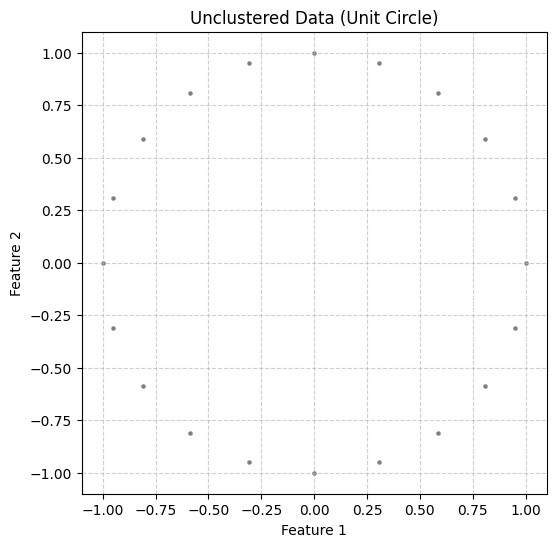

In [8]:
# Helper function to visualize clusters
def display_cluster(X, km=None, num_clusters=None, title=""):
    """Visualizes the clustered or unclustered data."""
    plt.figure(figsize=(6,6))
    
    if km is None:
        # Unclustered data
        plt.scatter(X[:, 0], X[:, 1], c='gray', marker='.', s=20)
    else:
        # Clustered data
        plt.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis', marker='.', s=20)
        
        # Plot centroids if available
        if hasattr(km, 'cluster_centers_'):
            centers = km.cluster_centers_
            plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, alpha=0.7)
            
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


# Create dataset (points on a unit circle)
angle = np.linspace(0, 2 * np.pi, 20, endpoint=False)
X = np.append([np.cos(angle)], [np.sin(angle)], axis=0).transpose()

# Visualize unclustered data
display_cluster(X, title="Unclustered Data (Unit Circle)")

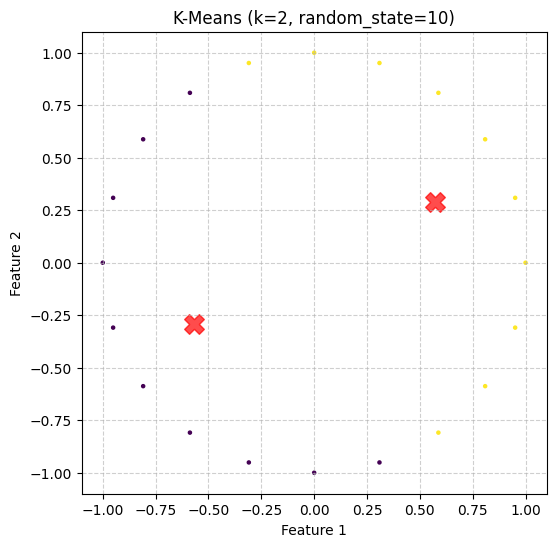

In [9]:
# K-Means with random_state=10
num_clusters = 2
km = KMeans(n_clusters=num_clusters, random_state=10, n_init=1)
km.fit(X)
display_cluster(X, km, num_clusters, title="K-Means (k=2, random_state=10)")

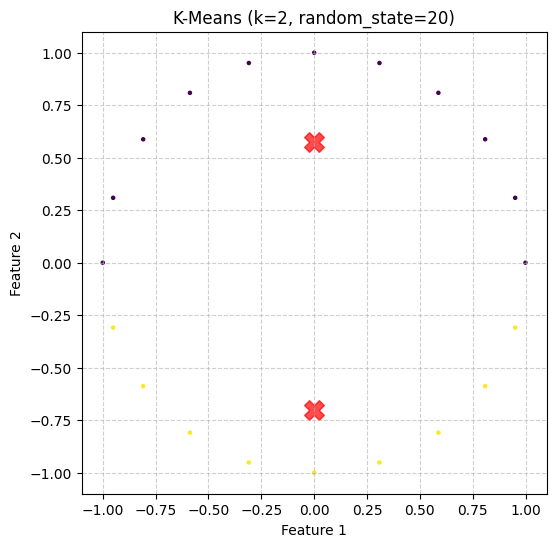

In [10]:
# K-Means with random_state=20
km = KMeans(n_clusters=num_clusters, random_state=20, n_init=1)
km.fit(X)
display_cluster(X, km, num_clusters, title="K-Means (k=2, random_state=20)")

**Observations:** 

The resulting clusters differ due to different initial centroid positions. Setting random_state ensures reproducibility, but varying it shows how the choice of starting point heavily influences the final cluster partitioning, highlighting the local minima problem.

**Result:** 

The clusters differ because K-Means is sensitive to initial centroid placement. Try `random_state=30 or 40` to see further variations, demonstrating that different random seeds lead to different convergence points.

# Finding Optimal Number of Clusters

## Elbow Method

**Theories and Concepts**

Choosing the optimal number of clusters (k) is a critical, subjective challenge in K-Means, as the algorithm requires k to be pre-specified. The goal is to find a k that provides a good trade-off between model complexity and cluster quality. The Elbow Method is a heuristic technique used to estimate this optimal value.

- **Inertia (WCSS) :** This is the metric plotted on the y-axis. It stands for Within-Cluster Sum of Squares and is the sum of squared distances of samples to their closest cluster center. By definition, increasing k always reduces inertia because adding a centroid can only bring data points closer to their assigned center, but this reduction comes at the cost of complexity.
- **Diminishing Returns :** The core principle of the Elbow Method. As k increases, the marginal benefit (reduction in inertia) from adding a new cluster decreases. The "elbow" represents the point of diminishing returns, where adding another cluster provides minimal additional benefit.
- **Model Complexity vs. Cluster Quality :** The method seeks to balance these two factors. A very small k results in underfitting (high inertia, poorly defined clusters). A very large k results in overfitting (low inertia, clusters are too small and lose generalization). The elbow is the point of optimal balance.
- **Non-Convexity :** The Elbow Method is a visual aid and relies on the curve having a clear, distinguishable bend. In many real-world, highly complex, or non-convex datasets, the "elbow" may be ambiguous or non-existent, making the choice of k more difficult.
- **Alternative Method:** Silhouette Analysis	The Silhouette Score is a quantitative alternative. It measures how similar an object is to its own cluster compared to other clusters. The optimal k is usually the one that yields the highest average Silhouette Score, providing a stronger, quantitative basis than visual inspection.

**The Elbow Method Procedure:**

- Run K-Means for a range of k values (e.g., `k=1` to `k=10`).
- Compute the Inertia (WCSS) for each k.
- Plot Inertia vs. k.
- The "elbow" point , where the plot sharply bends and inertia begins to decrease more slowly, indicates the optimal k.

**Inertia and Edge Cases:**

- If k equals the number of data points (`n`), each point becomes its own cluster. The distance from the point to its centroid is 0, resulting in Inertia=0. This is mathematically minimum but impractical as it overfits the data entirely and loses the purpose of generalization.
- For `k=1`, all data points belong to a single cluster centered at the grand mean of the data, resulting in the maximum possible inertia.

**Applying the Elbow Method**

A synthetic dataset with four clusters will be created and use the elbow method to find the optimal $ k $.

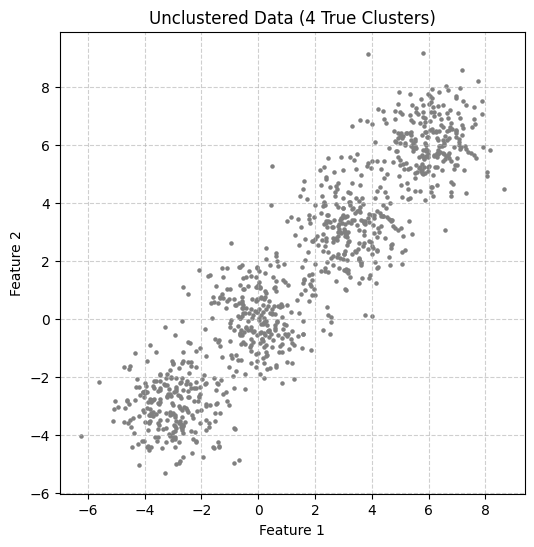

In [ ]:
# Define Helper Function for Visualization
def display_cluster(X, km=None, num_clusters=None, title=""):
    """Visualizes the clustered or unclustered data."""
    plt.figure(figsize=(6,6))
    
    if km is None:
        # Unclustered data
        plt.scatter(X[:, 0], X[:, 1], c='gray', marker='.', s=20)
    else:
        # Clustered data
        plt.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis', marker='.', s=20)
        
        # Plot centroids if available
        if hasattr(km, 'cluster_centers_'):
            centers = km.cluster_centers_
            plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, alpha=0.7)
            
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Create Synthetic Dataset + Create dataset with 4 clusters
n_samples = 1000
centers = [(-3, -3), (0, 0), (3, 3), (6, 6)]
X, y = make_blobs(n_samples=n_samples, n_features=2, cluster_std=1.0, centers=centers, shuffle=False, random_state=42)

# Visualize unclustered data
display_cluster(X, title="Unclustered Data (4 True Clusters)")

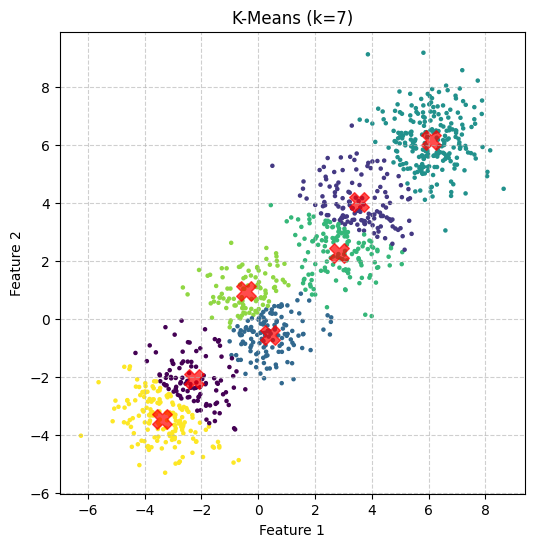

In [13]:
# K-Means with k=7
num_clusters = 7
km = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
km.fit(X)
display_cluster(X, km, num_clusters, title="K-Means (k=7)")

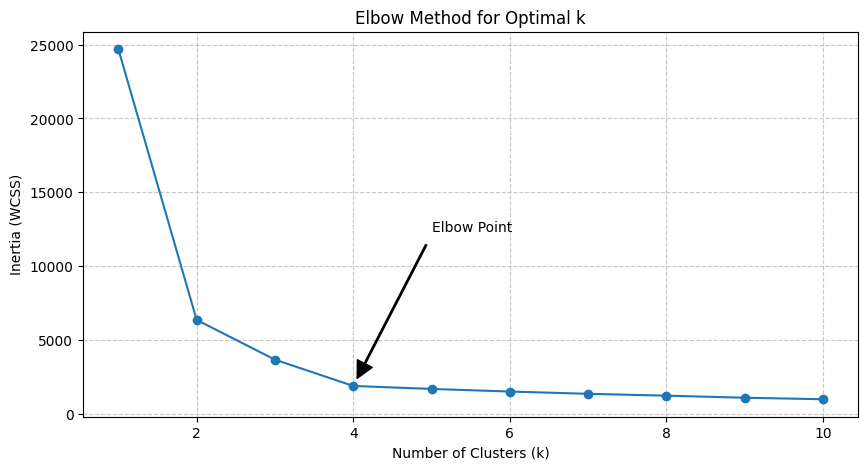


Observations:
The elbow occurs around k=4, where the marginal reduction in inertia significantly diminishes.
Inertia at k=4: 1880.17
Inertia at k=5: 1678.18 (Diminishing return begins)


In [ ]:
# Compute inertia for k=1 to 10
inertia = []
list_num_clusters = list(range(1, 11))

for num_clusters in list_num_clusters:
    km = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 5))
plt.plot(list_num_clusters, inertia, marker='o', linestyle='-', color='tab:blue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')

# Add annotation to highlight the elbow point (k=4)
# Note: Since we know the true k is 4, we highlight 4.
plt.annotate('Elbow Point', 
             xy=(4, inertia[3]), 
             xytext=(5, np.max(inertia) / 2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             horizontalalignment='left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\nObservations:")
print("The elbow occurs around k=4, where the marginal reduction in inertia significantly diminishes.")
print(f"Inertia at k=4: {inertia[3]:.2f}")
print(f"Inertia at k=5: {inertia[4]:.2f} (Diminishing return begins)")

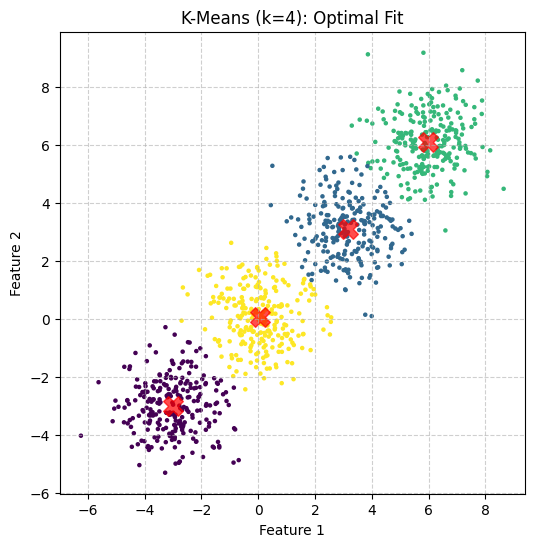

In [14]:
# K-Means with k=4 (Optimal clustering)
num_clusters_4 = 4
km_4 = KMeans(n_clusters=num_clusters_4, random_state=42, n_init=10)
km_4.fit(X)
display_cluster(X, km_4, num_clusters_4, title=f"K-Means (k={num_clusters_4}): Optimal Fit")

**Observations:** 

The elbow occurs around $ k=4 $, where adding more clusters yields diminishing reductions in inertia. This matches the visual structure of the dataset.

- **Elbow Point:** The elbow is at $ k=4 $, indicating four clusters are optimal.
- **Inertia with $ k = n $:** If the number of clusters equals the number of data points ($ k=1000 $), each point is its own cluster, so inertia = 0, but this overfits and is not useful.

## Alternative Methods

Besides the Elbow Method (based on Inertia/WCSS), here are the primary alternative methods for choosing the optimal k value for the K-Means algorithm:

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-k9u1{border-color:inherit;color:#1B1C1D;font-size:100%;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-k9u1">Method</th>
    <th class="tg-7zrl">Concept and Goal</th>
    <th class="tg-7zrl">Why It's Used</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Silhouette Score</td>
    <td class="tg-7zrl">Measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The Silhouette Coefficient ranges from −1 to +1. The optimal k maximizes the average silhouette score, indicating dense, well-separated clusters.</td>
    <td class="tg-0lax">It provides a single, robust quantitative metric, unlike the visual ambiguity of the Elbow Method.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Calinski-Harabasz Index (Variance Ratio Criterion)</td>
    <td class="tg-7zrl">Measures the ratio of the between-cluster dispersion (separation) to the within-cluster dispersion (cohesion). Higher scores correspond to models with better-defined clusters. The optimal k maximizes this index.</td>
    <td class="tg-0lax">It is fast to compute as it doesn't require calculating distances between all pairs of samples (like the Silhouette method does), making it efficient for large datasets.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Davies-Bouldin Index (DBI)</td>
    <td class="tg-7zrl">Measures the average "similarity" between clusters, where similarity is defined as the ratio of within-cluster distances to between-cluster distances. The goal is to minimize this index, as a lower DBI indicates better separation between clusters.</td>
    <td class="tg-0lax">It is simple and quick to calculate and is a good measure of cluster overlap.</td>
  </tr>
</tbody></table>

**Summary of Quantitative Metrics**

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-k9u1{border-color:inherit;color:#1B1C1D;font-size:100%;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-k9u1">Metric</th>
    <th class="tg-7zrl">Range</th>
    <th class="tg-7zrl">Optimal k</th>
    <th class="tg-7zrl">Interpretation</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Silhouette Score</td>
    <td class="tg-7zrl">[−1,+1]</td>
    <td class="tg-7zrl">Maximum (closest to +1)</td>
    <td class="tg-0lax">Well-separated clusters.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Calinski-Harabasz</td>
    <td class="tg-7zrl">[0,∞]</td>
    <td class="tg-7zrl">Maximum</td>
    <td class="tg-0lax">Highest ratio of separation to cohesion.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Davies-Bouldin Index</td>
    <td class="tg-7zrl">[0,∞]</td>
    <td class="tg-7zrl">Minimum (closest to 0)</td>
    <td class="tg-0lax">Lowest cluster overlap.</td>
  </tr>
</tbody>
</table>

### Silhouette Score

**Silhouette Score Foundations**

The Elbow Method is a powerful visual heuristic, but its reliability is limited by the ambiguity of the curve; a clear "elbow" often doesn't exist in real-world, high-dimensional, or complex datasets. Therefore, quantitative validation metrics are necessary to provide a more robust and objective way to determine the optimal number of clusters, k.

- **Silhouette Analysis :** A quantitative measure of how well-defined and separated clusters are. The Silhouette Score for a single data point measures how similar it is to its own cluster (cohesion) compared to the nearest neighboring cluster (separation). The overall score is the average across all data points.
- **Silhouette Coefficient (S(i)) :** Defined for a data point i as:$$S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$where a(i) is the average distance from i to all other points in its own cluster, and b(i) is the minimum average distance from i to points in a different cluster (the nearest neighbor cluster).

- **Score Interpretation :** The Silhouette Coefficient ranges from −1 to +1: +1 indicates that the point is perfectly clustered and far from the neighboring cluster; 0 suggests the point is on or very close to the decision boundary between two clusters; and −1 means the point has been misclassified into the wrong cluster.
- **Optimal k with Silhouette :** The optimal k is the value that yields the highest average Silhouette Score across all data points. This provides a single, unambiguous number, contrasting with the visual nature of the Elbow Method.
- **Calinski-Harabasz :** Index	Another common metric (also called the Variance Ratio Criterion). It is defined as the ratio of the between-cluster dispersion to the within-cluster dispersion. Higher scores correspond to better defined, denser clusters. It is generally faster to compute than the Silhouette Score.
- **Gap Statistic :** A more sophisticated method that compares the total within-cluster variation for different values of k to the expected within-cluster variation under a null reference distribution (i.e., a dataset with no obvious clustering). The optimal k is the one that maximizes the gap between the observed inertia and the reference inertia.

**Why It Matters:**

When the elbow is ambiguous or non-existent, quantitative metrics like the Silhouette Coefficient and the Calinski-Harabasz Index offer a more robust and objective way to choose k, ensuring the selected number of clusters maximizes internal cluster cohesion and external cluster separation.

The Silhouette Coefficient offers a more objective and quantitative measure than the Elbow Method for selecting the optimal number of clusters (k). While the Elbow Method relies on visually interpreting a bend in the Inertia curve, the Silhouette Score provides a single value for each k that quantifies both cluster cohesion (tightness) and separation (distance from other clusters). The k that yields the highest average Silhouette Score is typically the most justifiable choice.

**Silhouette Score Implementation**

**Data Preparation and Analysis**

- **Data Generation:** The process begins by using sklearn.datasets.make_blobs to create the synthetic dataset (X). This dataset contains 1,000 data points in 2D space, intentionally centered around four known points, simulating a scenario where the true value is K=4. The output is the initial data array X.
- **Silhouette Calculation Loop:** This is the primary analytical phase, iterating through K values from K=2 to K=10 (as the Silhouette Score requires a minimum of two clusters). In each iteration:

    - A K-Means model is fitted to the dataset (X).
    - The silhouette_score is calculated, measuring the quality of the resulting clusters.
    - The score is stored in the silhouette_scores list. The output includes a printout of the calculated score for each K.

- **Optimal K Determination:** The code identifies the optimal K value by finding the index corresponding to the maximum score in the silhouette_scores list using np.argmax(). This index is then used to retrieve the best K value (e.g., K=2 in the provided output) and reports its maximum corresponding score.

In [25]:
# Create Synthetic Dataset (Retained from above) 
n_samples = 1000
centers = [(-3, -3), (0, 0), (3, 3), (6, 6)]
X, y = make_blobs(n_samples=n_samples, n_features=2, cluster_std=1.0, centers=centers, shuffle=False, random_state=42)

# Compute Silhouette Score for k=2 to 10 
# Silhouette requires at least two clusters (k >= 2).
k_vals_sil = list(range(2, 11))
silhouette_scores = []

print("Calculating Silhouette Scores...")
for k in k_vals_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    score = silhouette_score(X, km.labels_)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")

# Find the optimal K (the one with the maximum score)
optimal_k_silhouette = k_vals_sil[np.argmax(silhouette_scores)]
max_score = np.max(silhouette_scores)

print("\n" + "=" * 50)
print(f"Optimal K by Silhouette Score: {optimal_k_silhouette} (Max Score: {max_score:.4f})")
print("=" * 50)

Calculating Silhouette Scores...
k=2: Silhouette Score = 0.6134
k=3: Silhouette Score = 0.5181
k=4: Silhouette Score = 0.5609
k=5: Silhouette Score = 0.4805
k=6: Silhouette Score = 0.4391
k=7: Silhouette Score = 0.3752
k=8: Silhouette Score = 0.3478
k=9: Silhouette Score = 0.3298
k=10: Silhouette Score = 0.3370

Optimal K by Silhouette Score: 2 (Max Score: 0.6134)


**Score Plotting** 

A line plot is generated to visualize the analysis results. It displays the tested K values (x-axis) against the Average Silhouette Score (y-axis), illustrating the trend in cluster quality as K increases. The plot highlights the optimal K found, showing how cluster quality changes.

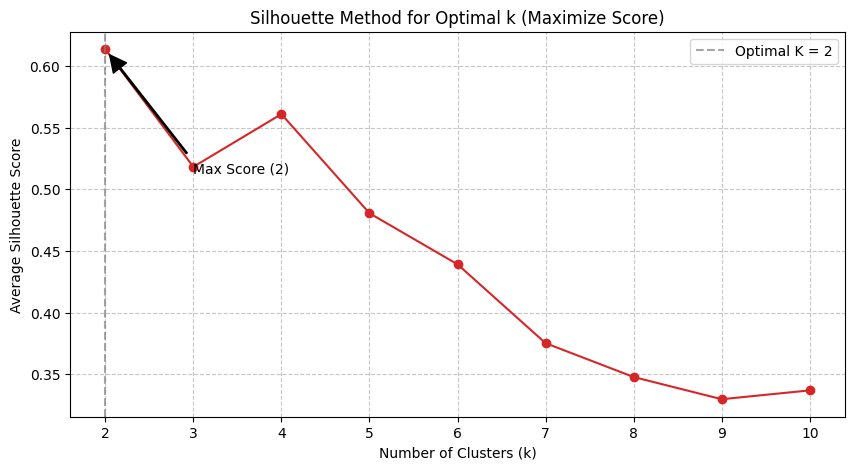

In [22]:
# Plot Silhouette Scores 
plt.figure(figsize=(10, 5))
plt.plot(k_vals_sil, silhouette_scores, marker='o', linestyle='-', color='tab:red')

# Highlight the optimal K value
plt.axvline(x=optimal_k_silhouette, color='gray', linestyle='--', alpha=0.7, 
            label=f'Optimal K = {optimal_k_silhouette}')
plt.annotate(f'Max Score ({optimal_k_silhouette})', 
             xy=(optimal_k_silhouette, max_score), 
             xytext=(optimal_k_silhouette + 1, max_score - 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             horizontalalignment='left')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Method for Optimal k (Maximize Score)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Final Visualization** 

Finally, the K-Means algorithm is run one last time using the determined optimal K (e.g., K=2). The clustered result is displayed as a scatter plot where data points are colored according to their final cluster assignments.

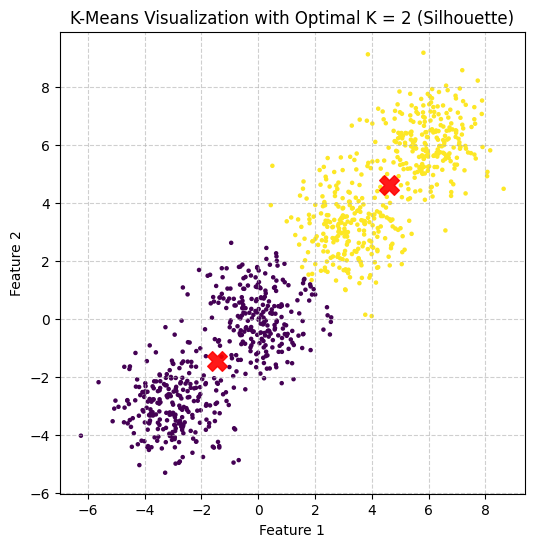

In [23]:
# Visualize Clustering with Optimal K
# Run K-Means one final time with the optimal K
km_optimal = KMeans(n_clusters=optimal_k_silhouette, random_state=42, n_init=10)
km_optimal.fit(X)

display_cluster(X, km_optimal, optimal_k_silhouette, 
                title=f"K-Means Visualization with Optimal K = {optimal_k_silhouette} (Silhouette)")

### Calinski-Harabasz Index

**Calinski-Harabasz Index Foundations**

The Calinski-Harabasz Index (CHI), also known as the Variance Ratio Criterion, is a quantitative metric used to determine the optimal number of clusters (K). It is a ratio that measures the separation between clusters relative to the compactness within clusters.

**Objective:** 

The goal is to maximize the CHI score. A higher score indicates a better partitioning of the data, where clusters are distinct and internally dense.

- **The Formula (Ratio of Variances):** The index is defined as a ratio involving two measures of dispersion:
- **Between-Cluster Dispersion (B):** Measures the squared distance of the cluster centroids from the overall grand mean of the data. This quantifies cluster separation. We want to maximize this.
- **Within-Cluster Dispersion (W):** Measures the sum of squared distances of data points from their respective cluster centroids (similar to Inertia/WCSS). This quantifies cluster compactness. We want to minimize following:$$CHI= B/ W × ((K−1)/ (N−K))$$ where N is the total number of data points, and K is the number of clusters.

- **Interpretation:** To maximize the CHI, the clusters must be far apart from one another (B is large) and the points within each cluster must be tightly packed around their centroid (W is small).
- **Advantage:** Unlike the Silhouette Score, the Calinski-Harabasz Index is based on distances to cluster means rather than distances between all data points. This makes it significantly faster to compute for large datasets $(O(N) or O(N×K))$ compared to Silhouette's quadratic complexity $(O(N^2))$.

**Applying Calinski-Harabasz Index**

The process is structured to test and evaluate clustering quality across a range of K values:

- **Helper Function (`display_cluster`):** A utility function is defined to visualize the results. It plots the data points, colors them based on their assigned cluster labels, and clearly marks the calculated cluster centers (centroids) with 'X' markers.

- **Data Generation:** The code uses sklearn.datasets.make_blobs to create the synthetic dataset (X), consisting of 1,000 2D points. Crucially, this data is deliberately constructed with four centers (i.e., the ground truth is K=4), allowing the metric's accuracy to be verified.

- **CHI Calculation Loop:** This is the core analytical step, iterating through potential K values from K=2 to K=10. In each loop:

    - A K-Means model is fitted to the dataset (X).
    - The calinski_harabasz_score is calculated based on the data and the resulting cluster labels.
    - The score is stored in the calinski_harabasz_scores list for later comparison.

- **Optimal K Determination:** After testing all K values, the code finds the optimal K by locating the index of the maximum score in the `calinski_harabasz_scores` list using `np.argmax()`. The output confirms the metric successfully identifies K=4 (with a max score of 4027.11), accurately reflecting the ground truth structure of the synthetic data.

In [28]:
# Define Helper Function for Visualization
def display_cluster(X, km=None, num_clusters=None, title=""):
    """Visualizes the clustered or unclustered data."""
    plt.figure(figsize=(6,6))
    
    if km is None:
        plt.scatter(X[:, 0], X[:, 1], c='gray', marker='.', s=20)
    else:
        plt.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis', marker='.', s=20)
        
        if hasattr(km, 'cluster_centers_'):
            centers = km.cluster_centers_
            plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, alpha=0.7)
            
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Create Synthetic Dataset
n_samples = 1000
centers = [(-3, -3), (0, 0), (3, 3), (6, 6)]
X, y = make_blobs(n_samples=n_samples, n_features=2, cluster_std=1.0, centers=centers, shuffle=False, random_state=42)

# Compute Calinski-Harabasz Index for k=2 to 10
# CH Index requires at least two clusters (k >= 2).
k_vals_ch = list(range(2, 11))
calinski_harabasz_scores = []

print("Calculating Calinski-Harabasz Index...")
for k in k_vals_ch:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    score = calinski_harabasz_score(X, km.labels_)
    calinski_harabasz_scores.append(score)
    print(f"k={k}: Calinski-Harabasz Score = {score:.2f}")

# Find the optimal K (the one with the maximum score)
optimal_k_ch = k_vals_ch[np.argmax(calinski_harabasz_scores)]
max_score_ch = np.max(calinski_harabasz_scores)

print("\n" + "=" * 50)
print(f"Optimal K by Calinski-Harabasz Index: {optimal_k_ch} (Max Score: {max_score_ch:.2f})")
print("=" * 50)

Calculating Calinski-Harabasz Index...
k=2: Calinski-Harabasz Score = 2881.32
k=3: Calinski-Harabasz Score = 2862.43
k=4: Calinski-Harabasz Score = 4027.11
k=5: Calinski-Harabasz Score = 3410.42
k=6: Calinski-Harabasz Score = 3070.70
k=7: Calinski-Harabasz Score = 2865.10
k=8: Calinski-Harabasz Score = 2720.94
k=9: Calinski-Harabasz Score = 2703.57
k=10: Calinski-Harabasz Score = 2657.99

Optimal K by Calinski-Harabasz Index: 4 (Max Score: 4027.11)


**Score Plotting** 

A line plot is generated to visualize the findings. It plots K (x-axis) against the Average CHI Score (y-axis). The plot distinctly shows the peak score and includes annotations to highlight the optimal K=4.

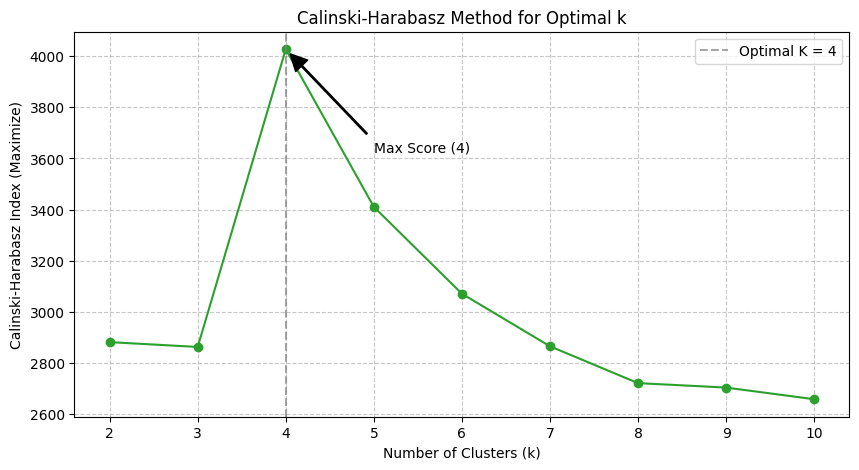

In [30]:
# Plot Calinski-Harabasz Scores
plt.figure(figsize=(10, 5))
plt.plot(k_vals_ch, calinski_harabasz_scores, marker='o', linestyle='-', color='tab:green')

# Highlight the optimal K value
plt.axvline(x=optimal_k_ch, color='gray', linestyle='--', alpha=0.7, 
            label=f'Optimal K = {optimal_k_ch}')
plt.annotate(f'Max Score ({optimal_k_ch})', 
             xy=(optimal_k_ch, max_score_ch), 
             xytext=(optimal_k_ch + 1, max_score_ch * 0.9),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             horizontalalignment='left')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Calinski-Harabasz Index (Maximize)')
plt.title('Calinski-Harabasz Method for Optimal k')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Final Visualization** 

Finally, a K-Means model is run once more using the optimal K=4. The final clustered result is displayed using the display_cluster function, visually confirming that the data is correctly partitioned into four distinct and well-separated groups.

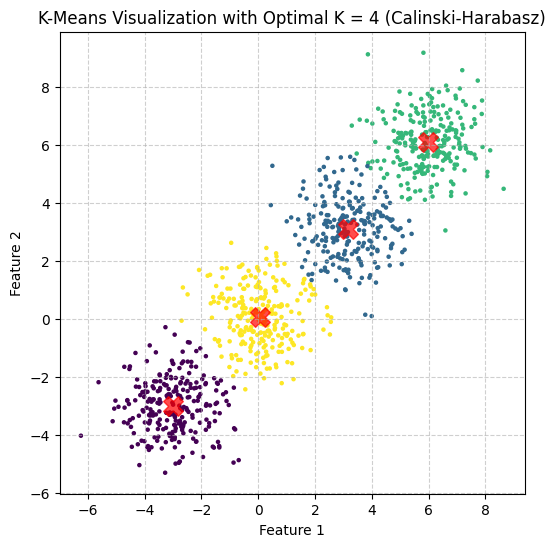

In [31]:
# Visualize Clustering with Optimal K 
# Run K-Means one final time with the optimal K
km_optimal_ch = KMeans(n_clusters=optimal_k_ch, random_state=42, n_init=10)
km_optimal_ch.fit(X)

display_cluster(X, km_optimal_ch, optimal_k_ch, 
                title=f"K-Means Visualization with Optimal K = {optimal_k_ch} (Calinski-Harabasz)")

### Davies-Bouldin Index

**Davies-Bouldin Index Foundations**

The Davies-Bouldin Index (DBI) is an internal quantitative metric used to determine the optimal number of clusters (K) by measuring the average similarity between each cluster and its most similar neighbor.

**Objective:** The goal is to minimize the DBI score. A lower score indicates better clustering, meaning the clusters are well-separated and internally dense.

**The Similarity Measure $(Rij)$:** The index is based on a similarity measure calculated between any two clusters (i and j), defined as:

$$R_{ij} = \frac{s_i + s_j}{d(c_i, c_j)}$$

where:
* $s_i$ is the **Cluster Size/Dispersion** (average distance of points in cluster $i$ to its centroid $c_i$). This quantifies cluster **compactness** (we want $s_i$ small).
* $d(c_i, c_j)$ is the **Distance Between Centroids** of cluster $i$ and $j$. This quantifies cluster **separation** (we want this large).

To get a low Rij, you need low dispersion (si,sj) and high separation (d(ci,cj)).

**The Index Calculation:** The DBI is the average of the maximum similarity ratio found for each cluster.

$$DBI = \frac{1}{K} \sum_{i=1}^{K} \max_{j \neq i} (R_{ij})$$

By taking the $\max R_{ij}$, the index focuses on the worst-case separation for each cluster - its closest, most similar neighbor. Averaging these worst-case scores gives a robust measure of overall cluster distinctness.

**Optimal K:** The value of K that yields the minimum DBI is chosen as the optimal number of clusters.

**Davies-Bouldin Index Implementation**

The code below executes a structured workflow using the Davies-Bouldin Index (DBI) to determine the optimal number of clusters (K) for a synthetic dataset. The DBI is a metric where lower scores indicate better clustering.The code systematically tests and evaluates clustering solutions across a range of K values to find the configuration that maximizes cluster distinctness and compactness.

- **Helper Function (display_cluster):** A utility function is included to visualize the clustering results. It generates a scatter plot of the data points, coloring them according to their cluster assignment, and clearly marks the calculated cluster centers (centroids) with 'X' markers.

- **Data Generation:** The code uses `sklearn.datasets.make_blobs` to create the synthetic 2D dataset (X) of 1,000 points. This data is intentionally set up with four distinct centers (meaning the ground truth is K=4).

- **DBI Calculation Loop:** This is the core analysis, iterating through potential K values from K=2 to K=10:

  - A K-Means model is fitted to the dataset (X).
  - The `davies_bouldin_score` is calculated for the resulting clusters.
  - The score is stored in the `davies_bouldin_scores` list.

- **Optimal K Determination:** The optimal K is found by locating the index corresponding to the minimum score in the `davies_bouldin_scores` list using `np.argmin()`. The analysis reports the lowest DBI score (0.5496) occurred at K=2.

In [3]:
# Define Helper Function for Visualization
def display_cluster(X, km=None, num_clusters=None, title=""):
    """Visualizes the clustered or unclustered data."""
    plt.figure(figsize=(6,6))
    
    if km is None:
        # Unclustered data
        plt.scatter(X[:, 0], X[:, 1], c='gray', marker='.', s=20)
    else:
        # Clustered data
        plt.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis', marker='.', s=20)
        
        # Plot centroids if available
        if hasattr(km, 'cluster_centers_'):
            centers = km.cluster_centers_
            plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, alpha=0.7)
            
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Create Synthetic Dataset
n_samples = 1000
centers = [(-3, -3), (0, 0), (3, 3), (6, 6)]
X, y = make_blobs(n_samples=n_samples, n_features=2, cluster_std=1.0, centers=centers, shuffle=False, random_state=42)

# Compute Davies-Bouldin Index for k=2 to 10
# DBI requires at least two clusters (k >= 2).
k_vals_db = list(range(2, 11))
davies_bouldin_scores = []

for k in k_vals_db:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    score = davies_bouldin_score(X, km.labels_)
    davies_bouldin_scores.append(score)

# Find the optimal K (the one that minimizes the score)
optimal_k_db = k_vals_db[np.argmin(davies_bouldin_scores)]
min_score_db = np.min(davies_bouldin_scores)

print("-" * 50)
print(f"Optimal K by Davies-Bouldin Index: {optimal_k_db} (Min Score: {min_score_db:.4f})")
print("-" * 50)

--------------------------------------------------
Optimal K by Davies-Bouldin Index: 2 (Min Score: 0.5496)
--------------------------------------------------


**Score Plotting** 

A line plot is generated to visualize the scores, plotting K (x-axis) against the DBI Score (y-axis). The plot highlights the point where the score reaches its minimum value, indicating the optimal K.

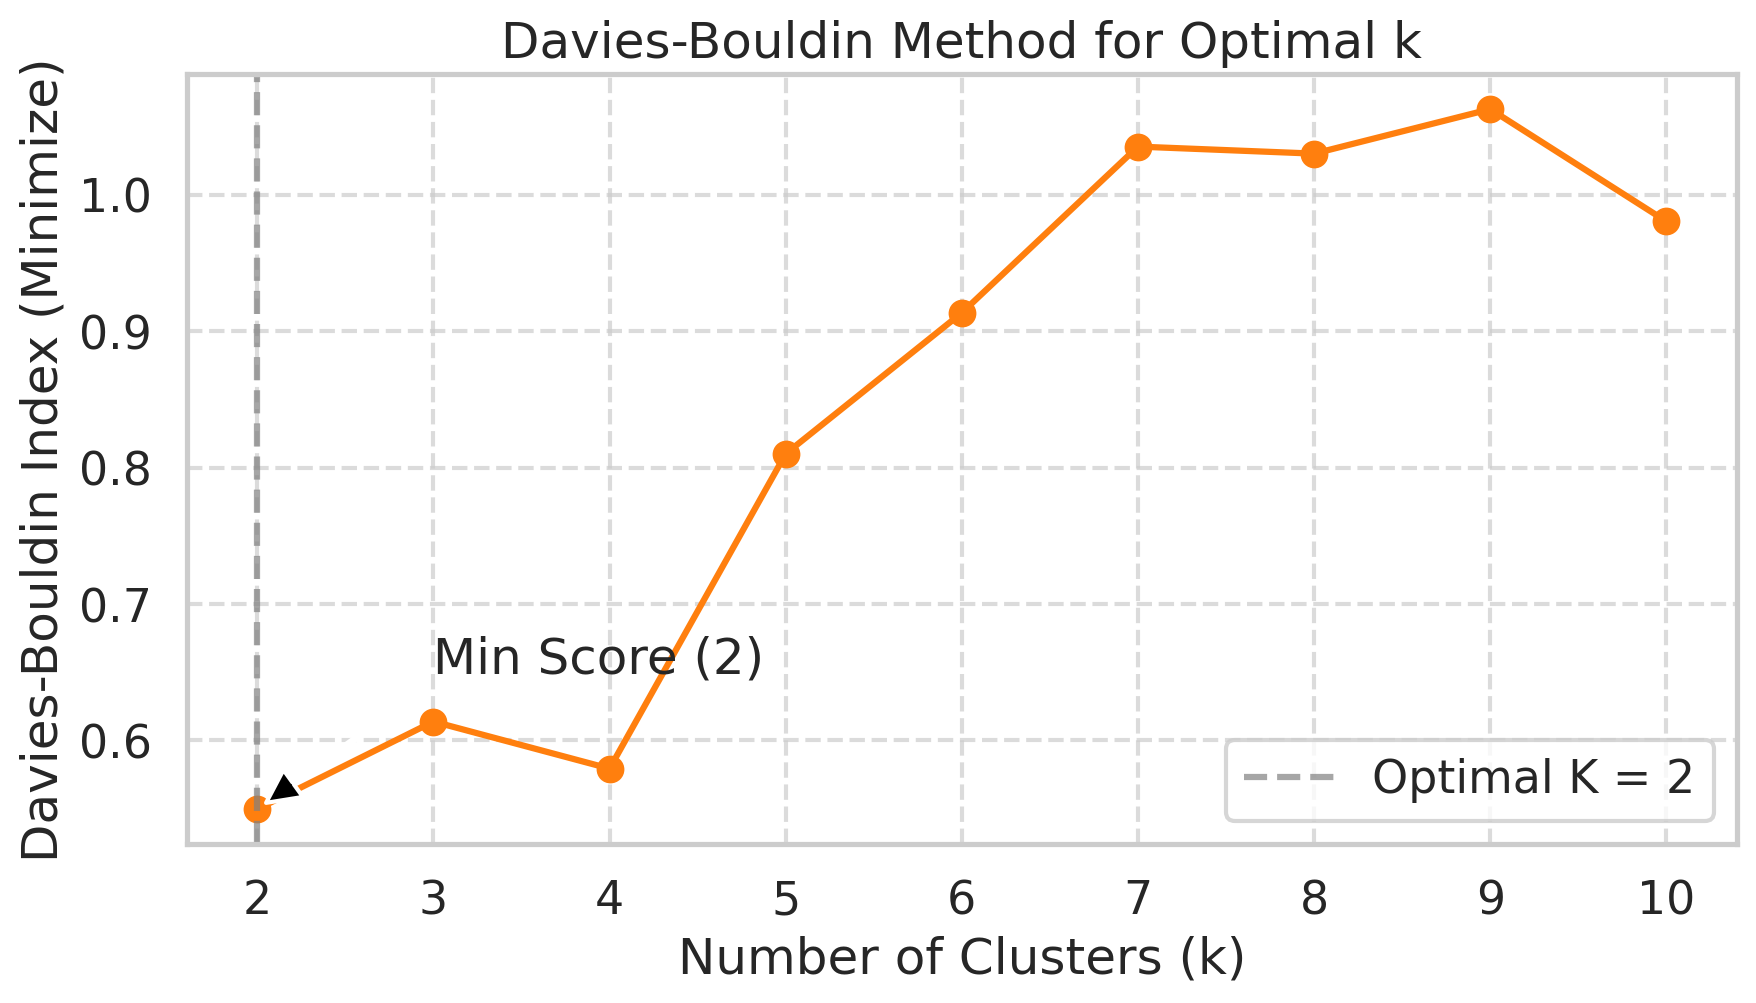

In [4]:
# Plot Davies-Bouldin Scores
plt.figure(figsize=(10, 5))
plt.plot(k_vals_db, davies_bouldin_scores, marker='o', linestyle='-', color='tab:orange')

# Highlight the optimal K value
plt.axvline(x=optimal_k_db, color='gray', linestyle='--', alpha=0.7, 
            label=f'Optimal K = {optimal_k_db}')
plt.annotate(f'Min Score ({optimal_k_db})', 
             xy=(optimal_k_db, min_score_db), 
             xytext=(optimal_k_db + 1, min_score_db + 0.1), # Adjust text position slightly
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             horizontalalignment='left')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index (Minimize)')
plt.title('Davies-Bouldin Method for Optimal k')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Final Visualization** 

A K-Means model is run one final time using the optimal K=2 identified by the DBI. The final clustered result is then displayed, showing the data partitioned into the two groups that the metric judged as having the best overall separation and compactness.

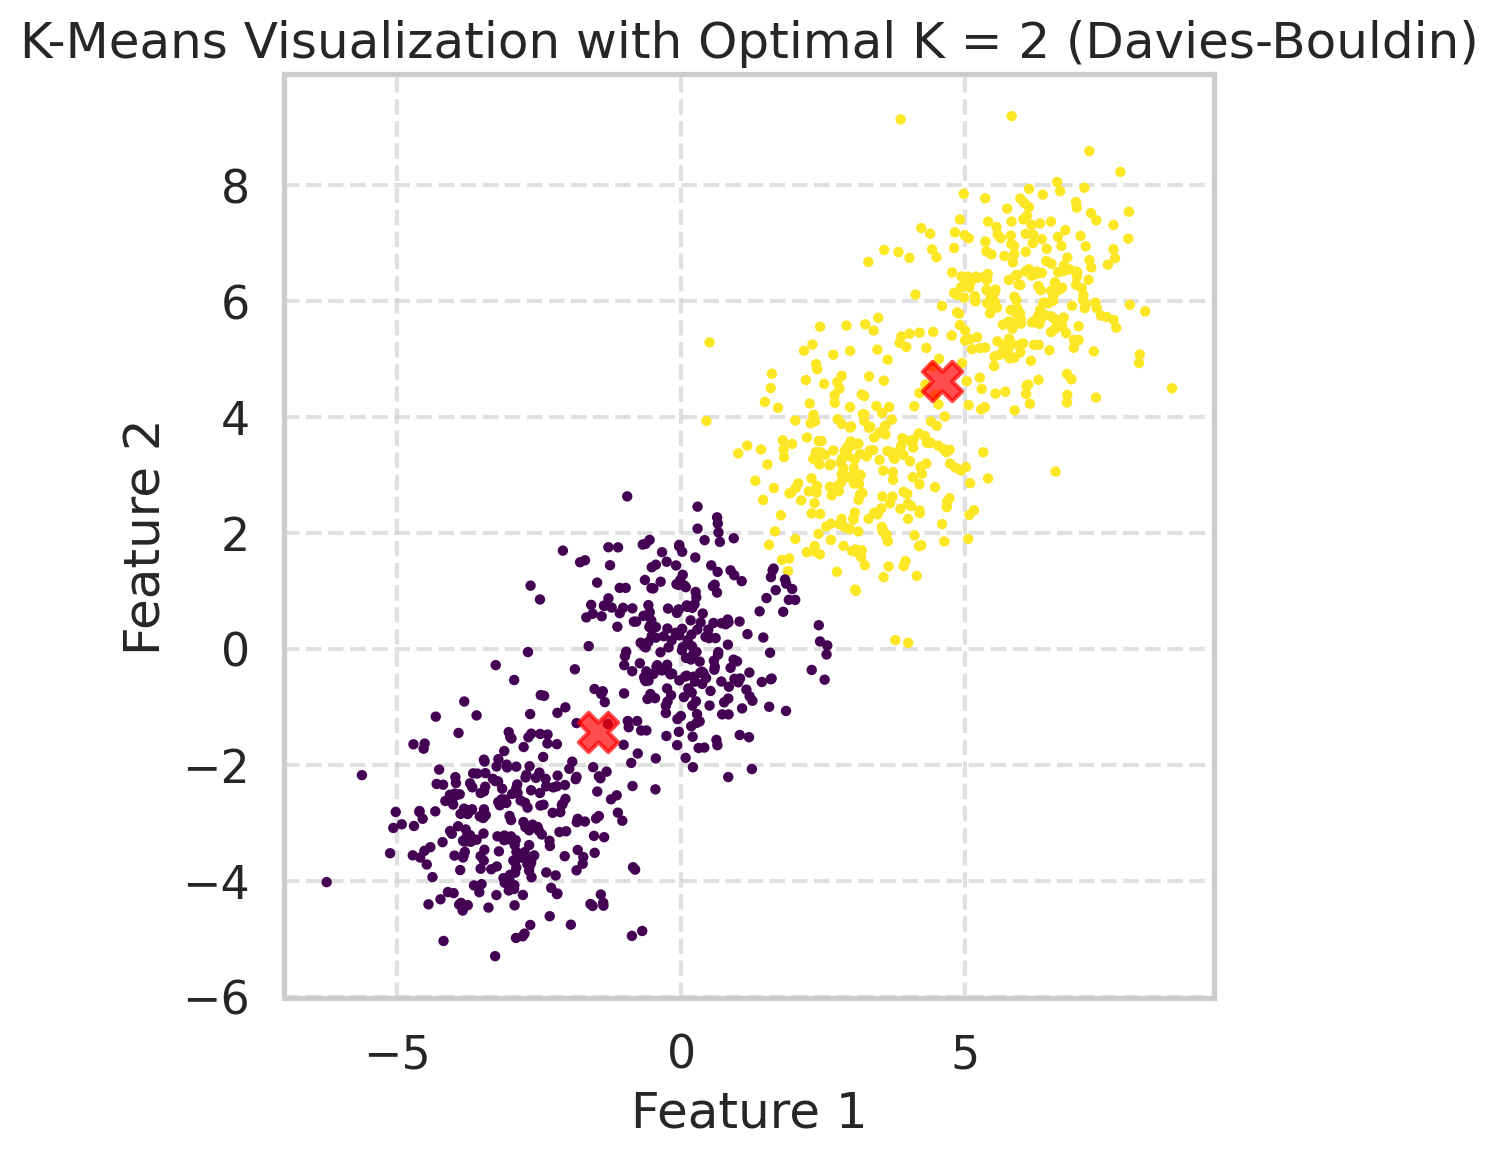

In [5]:
# Visualize Clustering with Optimal K
# Run K-Means one final time with the optimal K
km_optimal_db = KMeans(n_clusters=optimal_k_db, random_state=42, n_init=10)
km_optimal_db.fit(X)

display_cluster(X, km_optimal_db, optimal_k_db, 
                title=f"K-Means Visualization with Optimal K = {optimal_k_db} (Davies-Bouldin)")

# Each Method Result Comparisons

**The comparative evaluation of four different methods**

The comparative evaluation of four different methods used to determine the optimal number of clusters (K) for K-Means. This comparison is essential because, as the results demonstrate, different metrics often provide conflicting recommendations for K. The methods used—Inertia, Silhouette, Calinski-Harabasz, and Davies-Bouldin—are all intrinsic validation techniques. They evaluate a clustering solution purely based on the data's geometry, specifically looking at compactness (how tight clusters are) and separation (how far clusters are from each other).

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-k9u1{border-color:inherit;color:#1B1C1D;font-size:100%;text-align:left;vertical-align:bottom}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-k9u1">Method</th>
    <th class="tg-za14">Goal</th>
    <th class="tg-za14">Core Principle (What it measures)</th>
    <th class="tg-za14">Optimal K Rule</th>
    <th class="tg-0lax">Result on Data (K=4 ground truth)</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-za14">1. Inertia (Elbow)</td>
    <td class="tg-za14">Minimize</td>
    <td class="tg-za14">WCSS (Within-Cluster Sum of Squares). Measures compactness.</td>
    <td class="tg-za14">Find the K where the rate of decrease in WCSS slows significantly ("elbow").</td>
    <td class="tg-7zrl">K=4 (Visual)</td>
  </tr>
  <tr>
    <td class="tg-za14">2. Silhouette Score</td>
    <td class="tg-za14">Maximize (≈+1)</td>
    <td class="tg-za14">Cohesion vs. Separation. Balances tightness within clusters against distance to neighbors. Sensitive to density.</td>
    <td class="tg-za14">Highest average score.</td>
    <td class="tg-0lax">K=2 (Highest Score: 0.6134)</td>
  </tr>
  <tr>
    <td class="tg-za14">3. Calinski-Harabasz Index (CHI)</td>
    <td class="tg-za14">Maximize</td>
    <td class="tg-za14">Ratio of Between-Cluster Variance to Within-Cluster Variance. Rewards separated, dense clusters.</td>
    <td class="tg-za14">Highest score.</td>
    <td class="tg-0lax">K=4 (Highest Score: 4027.11)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">4. Davies-Bouldin Index (DBI)</td>
    <td class="tg-7zrl">Minimize (≈0)</td>
    <td class="tg-7zrl">Average measure of cluster similarity/overlap. Low score means low overlap and good separation.</td>
    <td class="tg-7zrl">Lowest average score.</td>
    <td class="tg-0lax">K=2 (Lowest Score: 0.5496)</td>
  </tr>
</tbody></table>

**Discrepancy in Results**

The synthetic dataset has four true, well-separated clusters.

- CHI and Inertia correctly recommend K=4. These metrics are good at finding the actual number of individual, compact groups.
- Silhouette and DBI recommend K=2. These metrics heavily prioritize separation. Because the four small blobs are widely spaced, merging them into two large, highly separated super-clusters results in the maximum possible boundary distance (high separation), thus boosting the Silhouette and minimizing the DBI, despite the loss of internal structure. This highlights the importance of using multiple metrics.

**Setup and Data Generation**

- **Helpers Function :** Defines the `display_cluster` function to visualize 2D clusters and their centroids.
- **Synthetic Dataset :** Uses `make_blobs` to create 1,000 data points (X) with four distinct centers (the known ground truth is K=4).
- **K Ranges :** Defines `k_vals_full` (K=1 to 10) for Inertia, and `k_vals_metrics` (K=2 to 10) for the other metrics (which cannot be calculated for K=1).

In [3]:
# Define Helper Function for Visualization
def display_cluster(X, km=None, num_clusters=None, title=""):
    """Visualizes the clustered or unclustered data."""
    plt.figure(figsize=(6,6))
    
    if km is None:
        # Unclustered data
        plt.scatter(X[:, 0], X[:, 1], c='gray', marker='.', s=20)
    else:
        # Clustered data
        plt.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis', marker='.', s=20)
        
        # Plot centroids if available
        if hasattr(km, 'cluster_centers_'):
            centers = km.cluster_centers_
            plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, alpha=0.7)
            
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Create Synthetic Dataset
n_samples = 1000
centers = [(-3, -3), (0, 0), (3, 3), (6, 6)]
X, y = make_blobs(n_samples=n_samples, n_features=2, cluster_std=1.0, centers=centers, shuffle=False, random_state=42)

# Define the range of k values
k_vals_full = list(range(1, 11)) # k=1 to 10 for Inertia
k_vals_metrics = list(range(2, 11)) # k=2 to 10 for Silhouette, CH, DB

**Consolidated Analysis Loop**

- **Consolidated Loop :** A single for loop efficiently iterates from K=1 to 10. In each iteration: 1. A K-Means model is fitted. 2. Inertia is recorded for all K. 3. The Silhouette, Calinski-Harabasz, and Davies-Bouldin scores are calculated and recorded for K≥2.
- **Optimal K Determination :** The `find_optimal_k helper` function automatically finds the maximum score for Silhouette and CHI, and the minimum score for DBI. The results are stored in `optimal_k_results`.

In [35]:
# INITIALIZE RESULT LISTS
# Inertia values will include k=1, others start at k=2
inertia_values = [] 
silhouette_scores = []
calinski_harabasz_values = []
davies_bouldin_values = []
optimal_k_results = {}

# CONSOLIDATED LOOP FOR ALL METRICS
print(f"Starting K-Means and Metric calculation for k=1 to 10...")

for k in k_vals_full:
    # Use max_iter=300 and n_init=10 as typical defaults
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    labels = kmeans.labels_

    # 1. INERTIA (WCSS) - Calculated for all K
    inertia_values.append(kmeans.inertia_)
    
    # 2-4. Quantitative Metrics - Require k > 1
    if k > 1:
        silhouette_scores.append(silhouette_score(X, labels))
        calinski_harabasz_values.append(calinski_harabasz_score(X, labels))
        davies_bouldin_values.append(davies_bouldin_score(X, labels))
    
    print(f"k={k:2d} done. Inertia: {kmeans.inertia_:.2f}")

# Determine Optimal K for Each Metric

def find_optimal_k(values, k_range, minimize=False):
    """Helper function to find the optimal k and score."""
    if minimize:
        optimal_index = np.argmin(values)
    else:
        optimal_index = np.argmax(values)
        
    optimal_k = k_range[optimal_index]
    optimal_score = values[optimal_index]
    return optimal_k, optimal_score

# Store results
optimal_k_results['Silhouette'] = find_optimal_k(silhouette_scores, k_vals_metrics, minimize=False)
optimal_k_results['Calinski-Harabasz'] = find_optimal_k(calinski_harabasz_values, k_vals_metrics, minimize=False)
optimal_k_results['Davies-Bouldin'] = find_optimal_k(davies_bouldin_values, k_vals_metrics, minimize=True)

Starting K-Means and Metric calculation for k=1 to 10...
k= 1 done. Inertia: 24686.43
k= 2 done. Inertia: 6350.87
k= 3 done. Inertia: 3661.60
k= 4 done. Inertia: 1880.17
k= 5 done. Inertia: 1678.18
k= 6 done. Inertia: 1501.04
k= 7 done. Inertia: 1348.20
k= 8 done. Inertia: 1222.09
k= 9 done. Inertia: 1081.55
k=10 done. Inertia: 981.13


In [4]:
# INITIALIZE RESULT LISTS
# Inertia values will include k=1, others start at k=2
inertia_values = [] 
silhouette_scores = []
calinski_harabasz_values = []
davies_bouldin_values = []
optimal_k_results = {}

# CONSOLIDATED LOOP FOR ALL METRICS
print(f"Starting K-Means and Metric calculation for k=1 to 10...")

for k in k_vals_full:
    # Use max_iter=300 and n_init=10 as typical defaults
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    labels = kmeans.labels_

    # 1. INERTIA (WCSS) - Calculated for all K
    inertia_values.append(kmeans.inertia_)
    
    # 2-4. Quantitative Metrics - Require k > 1
    if k > 1:
        silhouette_scores.append(silhouette_score(X, labels))
        calinski_harabasz_values.append(calinski_harabasz_score(X, labels))
        davies_bouldin_values.append(davies_bouldin_score(X, labels))
    
    print(f"k={k:2d} done. Inertia: {kmeans.inertia_:.2f}")

# Determine Optimal K for Each Metric

def find_optimal_k(values, k_range, minimize=False):
    """Helper function to find the optimal k and score."""
    if minimize:
        optimal_index = np.argmin(values)
    else:
        optimal_index = np.argmax(values)
        
    optimal_k = k_range[optimal_index]
    optimal_score = values[optimal_index]
    return optimal_k, optimal_score

# Store results
optimal_k_results['Silhouette'] = find_optimal_k(silhouette_scores, k_vals_metrics, minimize=False)
optimal_k_results['Calinski-Harabasz'] = find_optimal_k(calinski_harabasz_values, k_vals_metrics, minimize=False)
optimal_k_results['Davies-Bouldin'] = find_optimal_k(davies_bouldin_values, k_vals_metrics, minimize=True)

Starting K-Means and Metric calculation for k=1 to 10...
k= 1 done. Inertia: 24686.43
k= 2 done. Inertia: 6350.87
k= 3 done. Inertia: 3661.60
k= 4 done. Inertia: 1880.17
k= 5 done. Inertia: 1678.18
k= 6 done. Inertia: 1501.04
k= 7 done. Inertia: 1348.20
k= 8 done. Inertia: 1222.09
k= 9 done. Inertia: 1081.55
k=10 done. Inertia: 981.13


**Visualization and Comparison**

- **Metric Visualization Grid :** A 2×2 grid of plots is generated to compare the scores graphically. Each plot shows the score curve for K=1 to 10 (or K=2 to 10) and uses a vertical line to mark the optimal K identified by that specific metric.
- **Final Summary :** Prints a summary table that clearly lists the recommended optimal K value for all four methods (e.g., K=4 for CHI, K=2 for Silhouette). This is the key output for comparing the final recommendations.

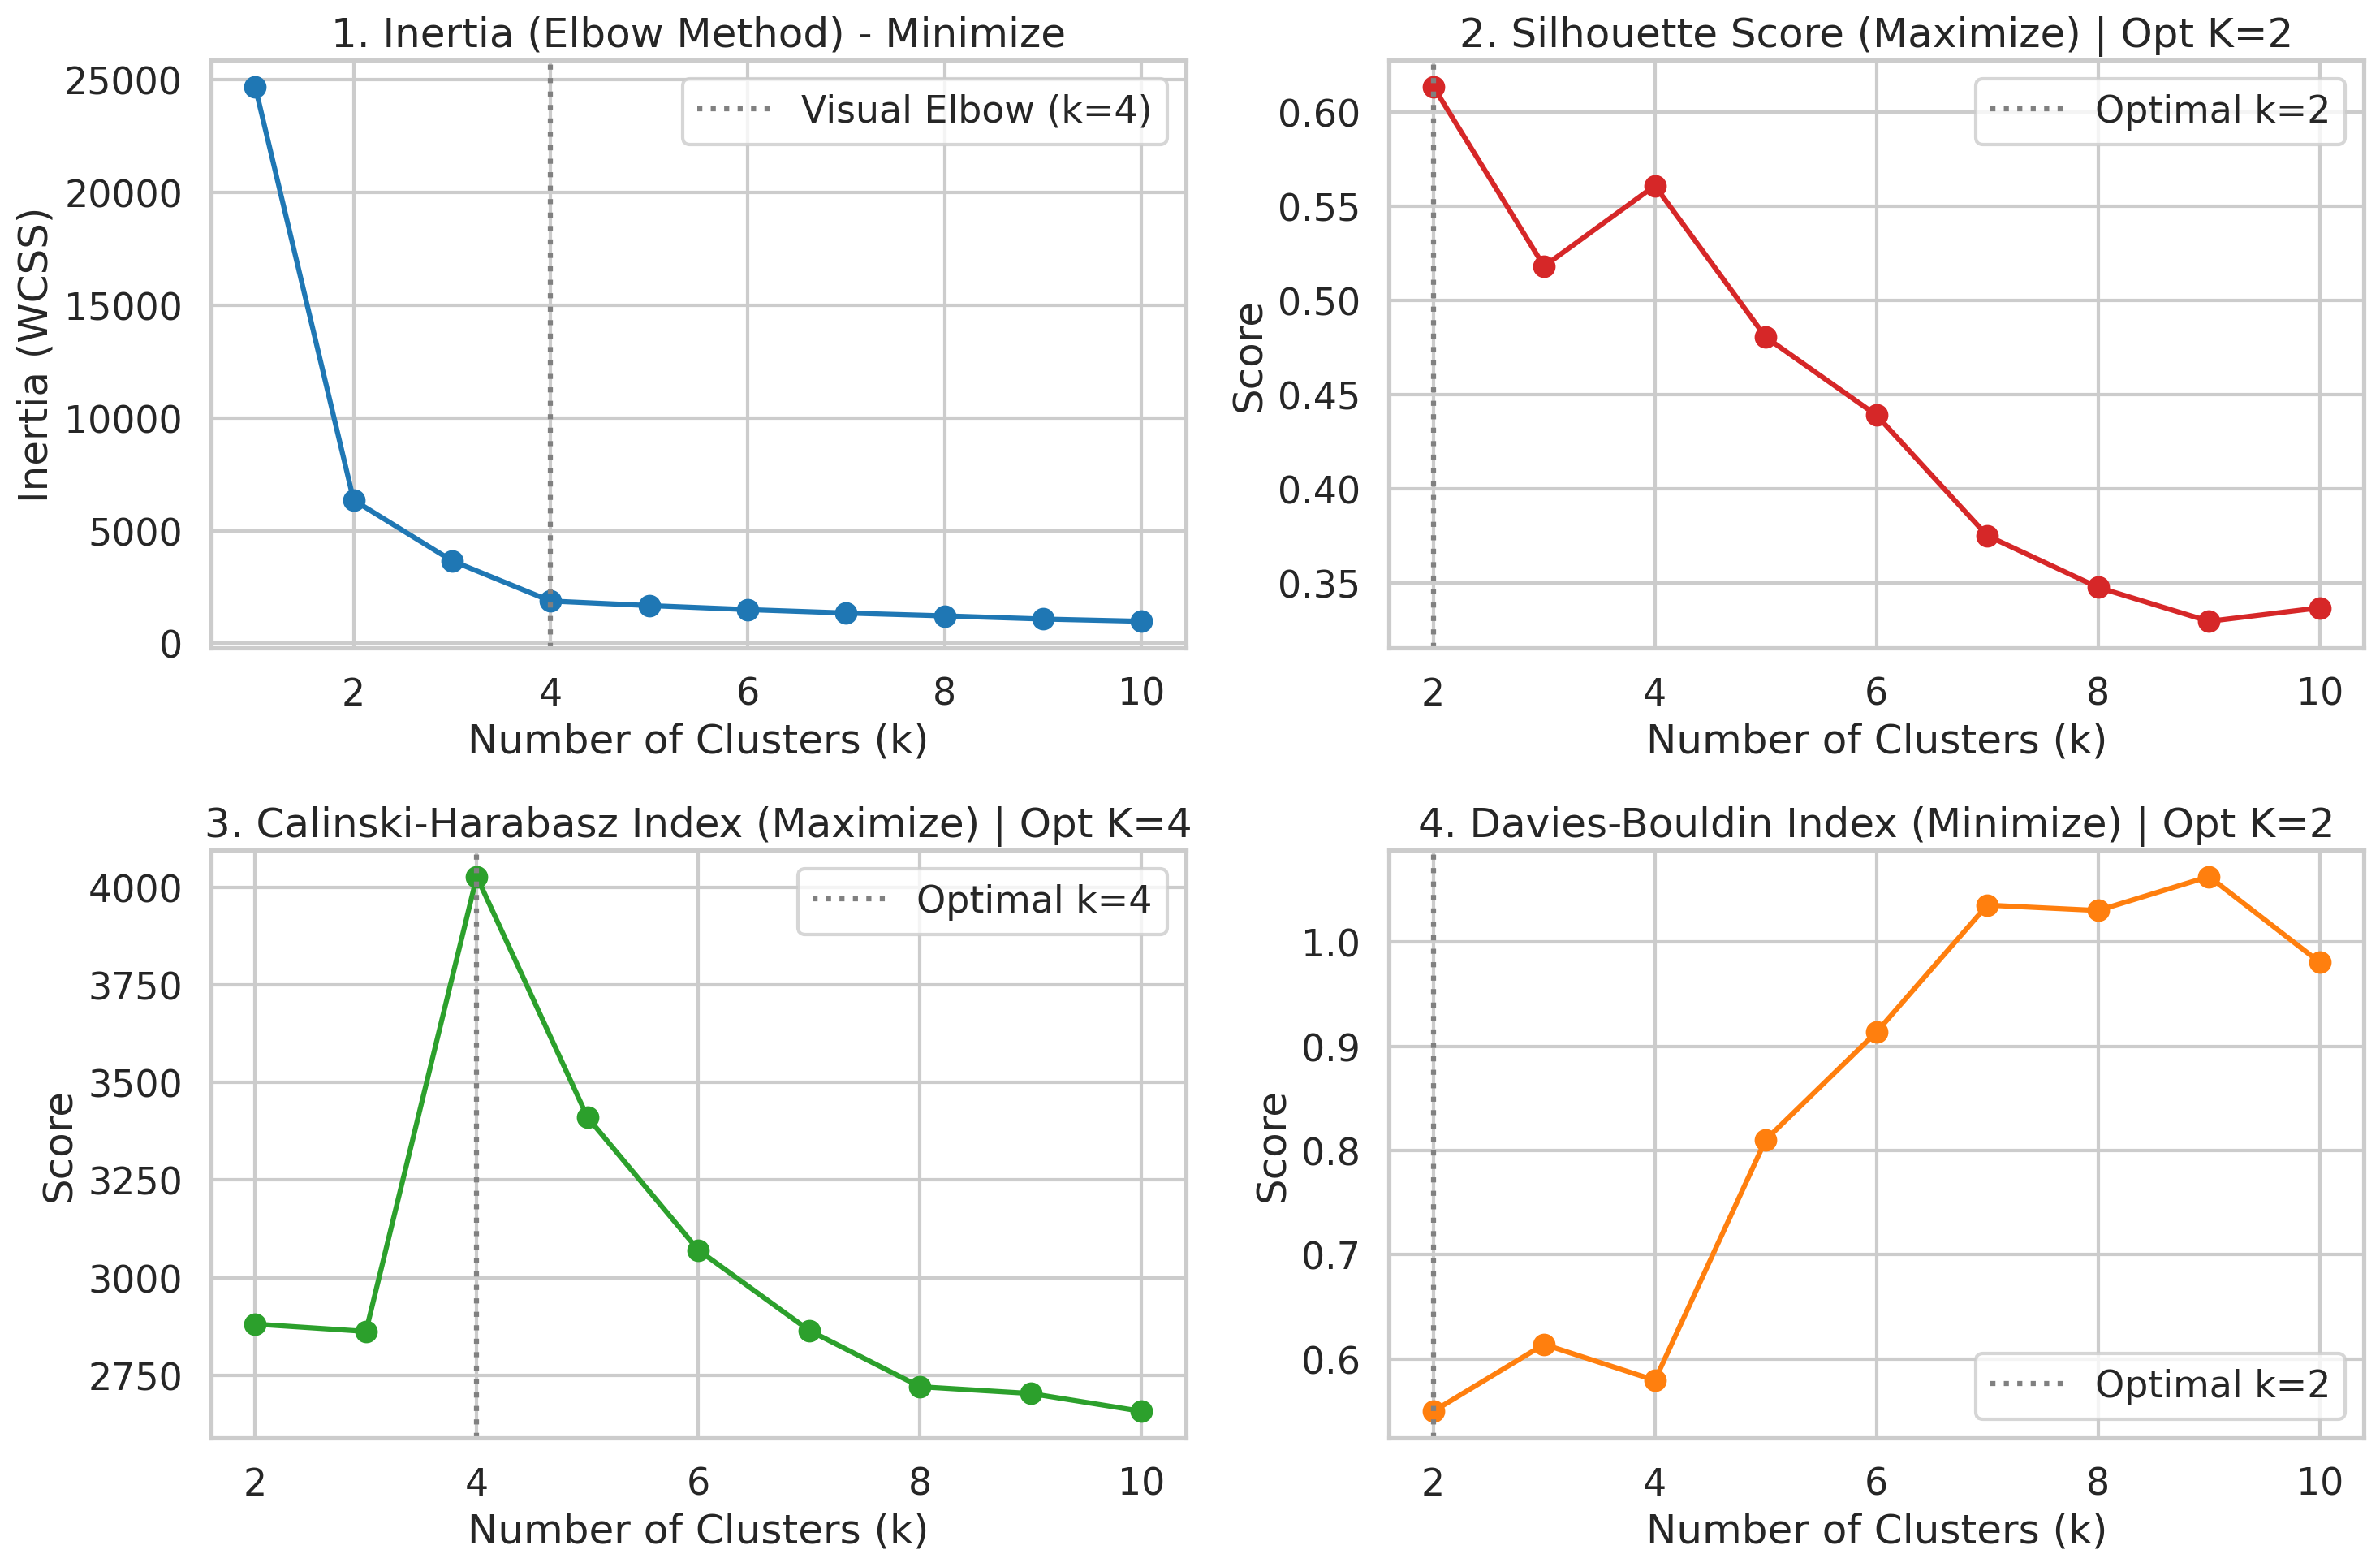


--------------------------------------------------
SUMMARY OF OPTIMAL K RECOMMENDATIONS:
--------------------------------------------------
1. Elbow Method (Visual): K=4 (Sharpest bend)
2. Silhouette Score (Maximize): K=2 (Score: 0.6134)
3. Calinski-Harabasz (Maximize): K=4 (Score: 4027.11)
4. Davies-Bouldin (Minimize): K=2 (Score: 0.5496)


In [5]:
# VISUALIZATION OF ALL METRICS (2x2 Grid)
plt.figure(figsize=(15, 10))

# --- PLOT 1: INERTIA (Elbow Method) ---
plt.subplot(2, 2, 1)
plt.plot(k_vals_full, inertia_values, marker='o', color='tab:blue')
plt.title('1. Inertia (Elbow Method) - Minimize')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.axvline(x=4, color='gray', linestyle=':', label='Visual Elbow (k=4)')
plt.legend()
plt.grid(True)

# --- PLOT 2: SILHOUETTE SCORE (Maximize) ---
optimal_k_sil, max_score_sil = optimal_k_results['Silhouette']
plt.subplot(2, 2, 2)
plt.plot(k_vals_metrics, silhouette_scores, marker='o', color='tab:red')
plt.axvline(x=optimal_k_sil, color='gray', linestyle=':', label=f'Optimal k={optimal_k_sil}')
plt.title(f'2. Silhouette Score (Maximize) | Opt K={optimal_k_sil}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- PLOT 3: CALINSKI-HARABASZ INDEX (Maximize) ---
optimal_k_ch, max_score_ch = optimal_k_results['Calinski-Harabasz']
plt.subplot(2, 2, 3)
plt.plot(k_vals_metrics, calinski_harabasz_values, marker='o', color='tab:green')
plt.axvline(x=optimal_k_ch, color='gray', linestyle=':', label=f'Optimal k={optimal_k_ch}')
plt.title(f'3. Calinski-Harabasz Index (Maximize) | Opt K={optimal_k_ch}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- PLOT 4: DAVIES-BOULDIN INDEX (Minimize) ---
optimal_k_db, min_score_db = optimal_k_results['Davies-Bouldin']
plt.subplot(2, 2, 4)
plt.plot(k_vals_metrics, davies_bouldin_values, marker='o', color='tab:orange')
plt.axvline(x=optimal_k_db, color='gray', linestyle=':', label=f'Optimal k={optimal_k_db}')
plt.title(f'4. Davies-Bouldin Index (Minimize) | Opt K={optimal_k_db}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print Final Summary
print("\n" + "-"*50)
print("SUMMARY OF OPTIMAL K RECOMMENDATIONS:")
print("-"*50)
print(f"1. Elbow Method (Visual): K=4 (Sharpest bend)")
print(f"2. Silhouette Score (Maximize): K={optimal_k_sil} (Score: {max_score_sil:.4f})")
print(f"3. Calinski-Harabasz (Maximize): K={optimal_k_ch} (Score: {max_score_ch:.2f})")
print(f"4. Davies-Bouldin (Minimize): K={optimal_k_db} (Score: {min_score_db:.4f})")

**Visualization and Comparison**

- **Clustering Visualization Grid (Second Code Block) :** Plots the actual clustering results for the four identified optimal K values (K=4 from Elbow/CHI and K=2 from Silhouette/DBI). This allows a user to visually inspect why the metrics produced different results and decide which solution better reflects the true data structure.

Optimal K determined by each method: {'Elbow (Visual)': 4, 'Silhouette (Max)': 2, 'Calinski-Harabasz (Max)': 4, 'Davies-Bouldin (Min)': 2}


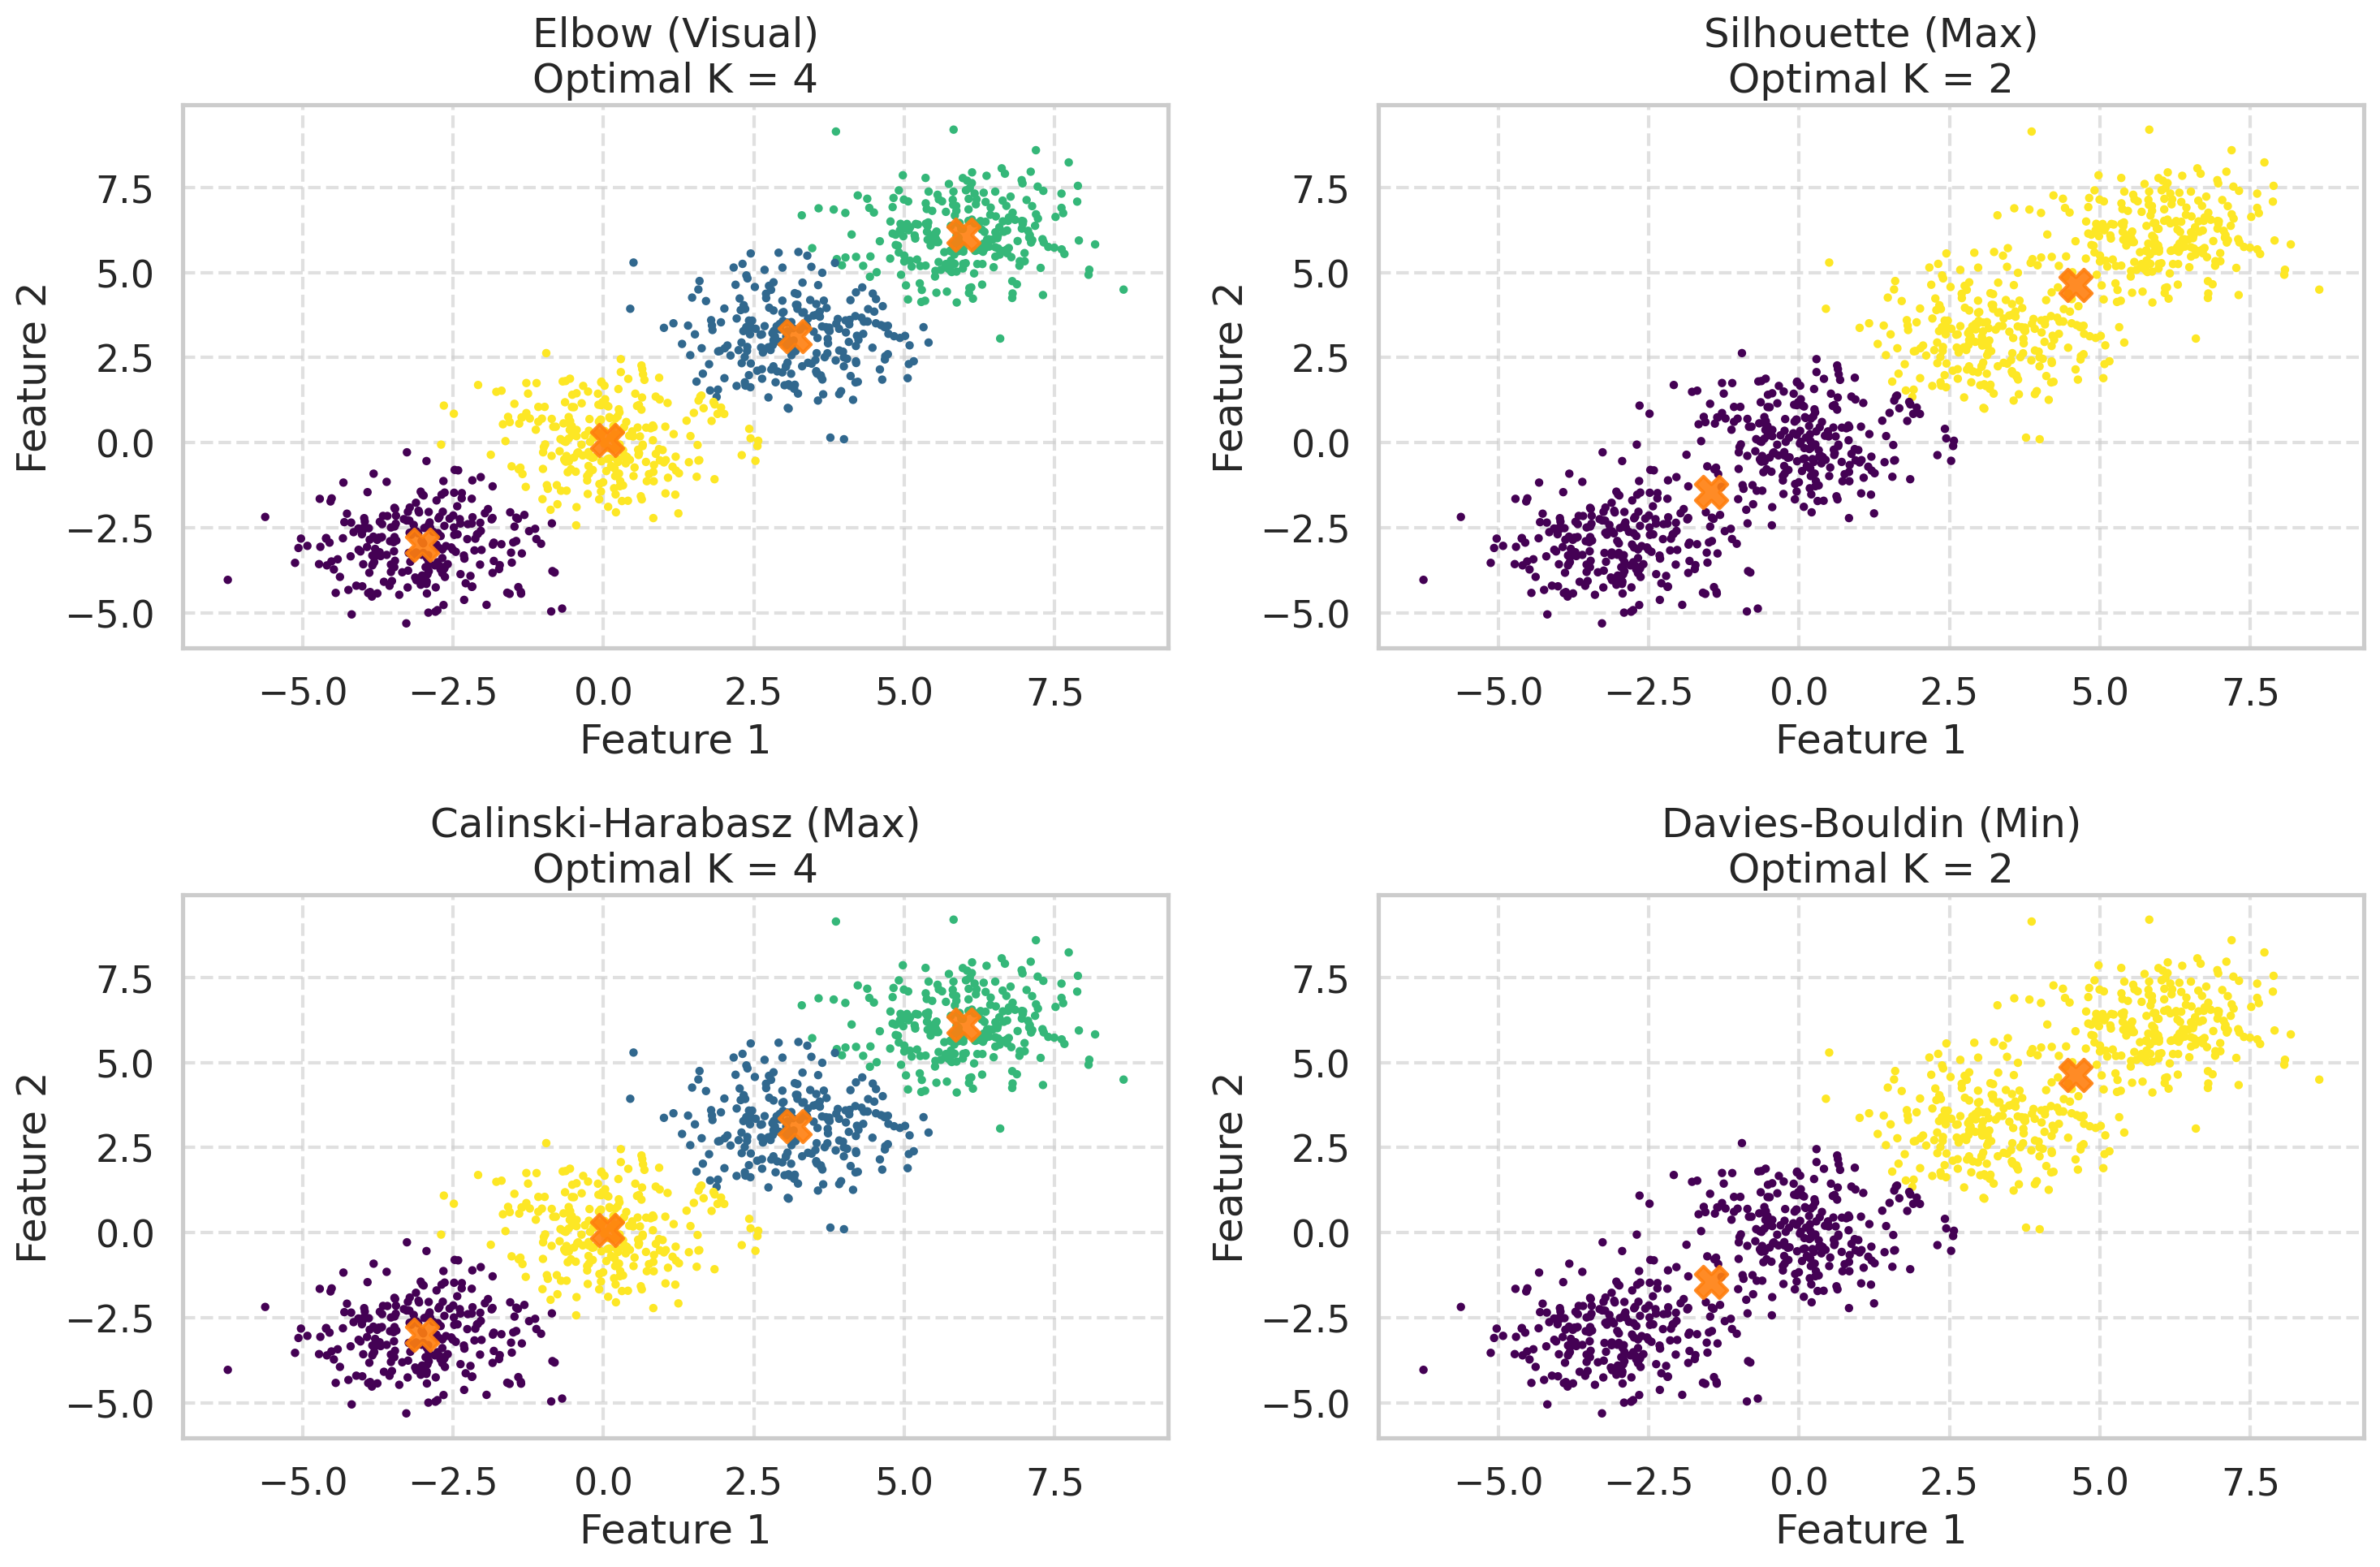

In [8]:
# Data Generation
n_samples = 1000
centers = [(-3, -3), (0, 0), (3, 3), (6, 6)]
X, y = make_blobs(n_samples=n_samples, n_features=2, cluster_std=1.0, centers=centers, shuffle=False, random_state=42)

# Define the range of k values (k=2 to 10 for metrics)
k_vals_metrics = list(range(2, 11))

# Calculation of all Metrics
silhouette_scores = []
calinski_harabasz_values = []
davies_bouldin_values = []
kmeans_models = {}

for k in k_vals_metrics:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    
    # Store the model for later visualization
    kmeans_models[k] = kmeans
    
    # Calculate and store scores
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))
    calinski_harabasz_values.append(calinski_harabasz_score(X, kmeans.labels_))
    davies_bouldin_values.append(davies_bouldin_score(X, kmeans.labels_))

# Determine Optimal K for Each Metric

# 1. Inertia (Elbow Method) - Manually set to the visually optimal K=4
optimal_k_elbow = 4 

# 2. Silhouette: Maximize
optimal_k_sil = k_vals_metrics[np.argmax(silhouette_scores)]

# 3. Calinski-Harabasz: Maximize
optimal_k_ch = k_vals_metrics[np.argmax(calinski_harabasz_values)]

# 4. Davies-Bouldin: Minimize
optimal_k_db = k_vals_metrics[np.argmin(davies_bouldin_values)]

# Store all optimal K values
optimal_ks = {
    'Elbow (Visual)': optimal_k_elbow,
    'Silhouette (Max)': optimal_k_sil,
    'Calinski-Harabasz (Max)': optimal_k_ch,
    'Davies-Bouldin (Min)': optimal_k_db
}

print(f"Optimal K determined by each method: {optimal_ks}")

# Ensure the K=4 model is available for the Elbow visualization
if optimal_k_elbow not in kmeans_models:
    kmeans_models[optimal_k_elbow] = KMeans(n_clusters=optimal_k_elbow, random_state=42, n_init=10).fit(X)

# Subplot Visualization of Clustering Results

plt.figure(figsize=(15, 10))

visualization_metrics = [
    ('Elbow (Visual)', optimal_k_elbow, 1, 'tab:orange'),
    ('Silhouette (Max)', optimal_k_sil, 2, 'tab:orange'),
    ('Calinski-Harabasz (Max)', optimal_k_ch, 3, 'tab:orange'),
    ('Davies-Bouldin (Min)', optimal_k_db, 4, 'tab:orange')
]

for title, k, subplot_num, color in visualization_metrics:
    km = kmeans_models[k]
    
    plt.subplot(2, 2, subplot_num)
    
    # Scatter plot the data points, colored by cluster label
    plt.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis', marker='.', s=20)
    
    # Plot the centroids
    centers = km.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1], c=color, marker='X', s=200, alpha=0.9, 
                label='Centroids')
            
    plt.title(f'{title}\nOptimal K = {k}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Conclusion 

**Conclusion of the K-Means Optimal K Comparative Analysis**

The project successfully implemented and compared four intrinsic validation techniques—Inertia (Elbow Method), Silhouette Score, Calinski-Harabasz Index (CHI), and Davies-Bouldin Index (DBI)—to determine the optimal number of clusters (K) for a synthetic dataset with a known ground truth of K=4.The key takeaway is that no single metric is universally superior; the choice of K depends on the definition of "optimal" clustering.

**Key Findings**

The analysis revealed a significant conflict in recommendations, demonstrating the varying priorities of each metric:

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-k9u1{border-color:inherit;color:#1B1C1D;font-size:100%;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-k9u1">Metric Type</th>
    <th class="tg-7zrl">Methods</th>
    <th class="tg-7zrl">Recommended K</th>
    <th class="tg-7zrl">Metric Priority</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Structure-Focused</td>
    <td class="tg-7zrl">Inertia (Elbow), CHI</td>
    <td class="tg-7zrl">K=4</td>
    <td class="tg-0lax">Internal Compactness and finding the granular structure of the data.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Separation-Focused</td>
    <td class="tg-7zrl">Silhouette, DBI</td>
    <td class="tg-7zrl">K=2</td>
    <td class="tg-0lax">External Separation (maximizing the distance between cluster boundaries).</td>
  </tr>
</tbody>
</table>

The ground truth of K=4 was correctly identified by the Elbow Method (visually) and the Calinski-Harabasz Index (quantitatively). Conversely, the Silhouette Score and Davies-Bouldin Index recommended K=2. This discrepancy occurred because the four true clusters were widely spaced, and merging them into two large "super-clusters" maximized the overall boundary distance, which these two metrics heavily reward, even at the cost of losing internal detail.

**Final Assessment**

The project affirms that a robust cluster analysis requires multiple validation methods and visual inspection. For datasets where internal structure (compactness) is critical, metrics like Inertia and CHI are more reliable. For datasets where simple, non-overlapping separation is the primary goal, Silhouette and DBI may dominate. Ultimately, while the optimal K value for this specific dataset based on its known structure is K=4, the project highlights the necessity for a data scientist to use qualitative visualization alongside quantitative metrics to make an informed, contextual decision, especially when metrics disagree.